# Single-TCR Model Test-Set Predictions

Recreates the ROC / PR curves across all single-TCR models using test-set predictions saved by `scripts/inference_test.py` and ground-truth labels from `data/ASdata-all/`.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm
from matplotlib.colors import to_hex
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [2]:
# Order shown in the reference figure
TCR_ORDER = [
    '4.1', '4.2', '4.3', '4.4',
    '8.4', '9.1',
    '19.2',
    '26.1', '26.2', 
    '28.1',
    '135.1', '135.3', '135.4', '135.7', '135.8',
    '019.1',
]

REPO_DIR = os.path.abspath('..')
PRED_TEMPLATE = os.path.join(
    REPO_DIR, 'model_outputs/single_tcr_loaded/lightning_logs/{tcr}_finetune_esm/outputs/y_pred_test.npy'
)
DATA_TEMPLATE = os.path.join(
    REPO_DIR, 'data/ASdata-all/{tcr}_neg=rnd234c0_pos=rnd4c5.csv'
)

In [3]:
def load_tcr(tcr_id):
    """Return (y_true, y_score) for a TCR's test split."""
    df = pd.read_csv(DATA_TEMPLATE.format(tcr=tcr_id))
    df = df.loc[df['Split'] == 'test']
    # match the filtering applied by DeepSequencingRawSequenceDataset
    df = df.loc[~df['Epitope'].str.contains('X')].reset_index(drop=True)

    y_pred_logits = np.load(PRED_TEMPLATE.format(tcr=tcr_id)).reshape(-1)
    y_true = df['Score'].to_numpy().astype(int)
    assert len(y_true) == len(y_pred_logits), (
        f'length mismatch for {tcr_id}: y_true={len(y_true)} vs y_pred={len(y_pred_logits)}'
    )
    return y_true, sigmoid(y_pred_logits)


results = {tcr: load_tcr(tcr) for tcr in TCR_ORDER}
{tcr: (yt.shape, ys.shape, int(yt.sum())) for tcr, (yt, ys) in results.items()}

{'4.1': ((69729,), (69729,), 287),
 '4.2': ((98756,), (98756,), 94),
 '4.3': ((97502,), (97502,), 577),
 '4.4': ((88359,), (88359,), 53),
 '8.4': ((55556,), (55556,), 780),
 '9.1': ((56953,), (56953,), 679),
 '19.2': ((74765,), (74765,), 128),
 '26.1': ((48546,), (48546,), 107),
 '26.2': ((65304,), (65304,), 78),
 '28.1': ((37097,), (37097,), 49),
 '135.1': ((9096,), (9096,), 81),
 '135.3': ((18968,), (18968,), 72),
 '135.4': ((48526,), (48526,), 204),
 '135.7': ((54699,), (54699,), 298),
 '135.8': ((37758,), (37758,), 70),
 '019.1': ((29330,), (29330,), 88)}

/var/tmp/pbs.7157889.polaris-pbs-01.hsn.cm.polaris.alcf.anl.gov/ipykernel_3867237/2676414476.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm', len(TCR_ORDER))


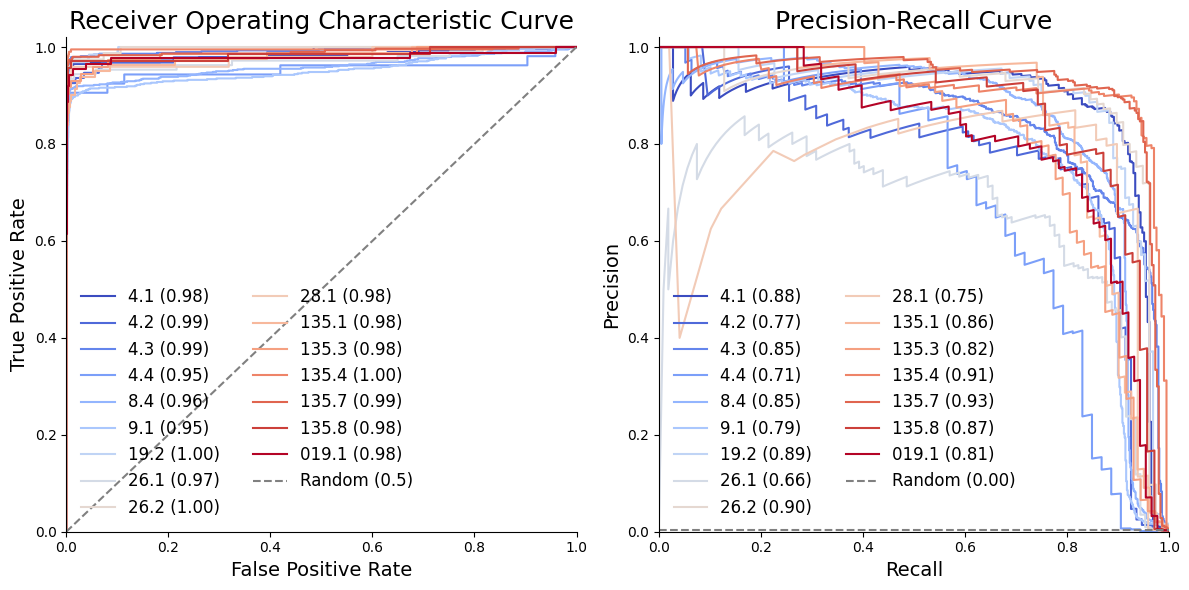

In [4]:
cmap = cm.get_cmap('coolwarm', len(TCR_ORDER))
colors = [to_hex(cmap(i)) for i in range(len(TCR_ORDER))]

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 6))

for tcr, color in zip(TCR_ORDER, colors):
    y_true, y_score = results[tcr]

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=color, lw=1.5, label=f'{tcr} ({roc_auc:.2f})')

    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    ax_pr.plot(recall, precision, color=color, lw=1.5, label=f'{tcr} ({ap:.2f})')

# random baselines
ax_roc.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random (0.5)')
# PR baseline = mean positive prevalence across TCR test sets
pr_baseline = float(np.mean([yt.mean() for yt, _ in results.values()]))
ax_pr.plot([0, 1], [pr_baseline, pr_baseline], linestyle='--', color='gray',
           label=f'Random ({pr_baseline:.2f})')

for ax, title, xlabel, ylabel in [
    (ax_roc, 'Receiver Operating Characteristic Curve', 'False Positive Rate', 'True Positive Rate'),
    (ax_pr, 'Precision-Recall Curve', 'Recall', 'Precision'),
]:
    ax.set_title(title, fontsize=18)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='lower left', fontsize=12, ncol=2, frameon=False)

plt.tight_layout()
plt.show()

## TCR 19.2 variants (C1–C5)

Same ROC / PR analysis as above, restricted to TCR 19.2 and its C1–C5 variants. Predictions and labels follow the identical naming convention (`{tcr}_finetune_esm` and `{tcr}_neg=rnd234c0_pos=rnd4c5.csv`), so we reuse `load_tcr` directly.

In [5]:
VARIANT_ORDER = ['19.2', '19.2C1', '19.2C2', '19.2C3', '19.2C4', '19.2C5']

variant_results = {tcr: load_tcr(tcr) for tcr in VARIANT_ORDER}
{tcr: (yt.shape, ys.shape, int(yt.sum())) for tcr, (yt, ys) in variant_results.items()}

{'19.2': ((74765,), (74765,), 128),
 '19.2C1': ((43928,), (43928,), 150),
 '19.2C2': ((28455,), (28455,), 99),
 '19.2C3': ((21840,), (21840,), 192),
 '19.2C4': ((29820,), (29820,), 56),
 '19.2C5': ((45066,), (45066,), 48)}

/var/tmp/pbs.7157889.polaris-pbs-01.hsn.cm.polaris.alcf.anl.gov/ipykernel_3867237/4086550647.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm', len(VARIANT_ORDER))


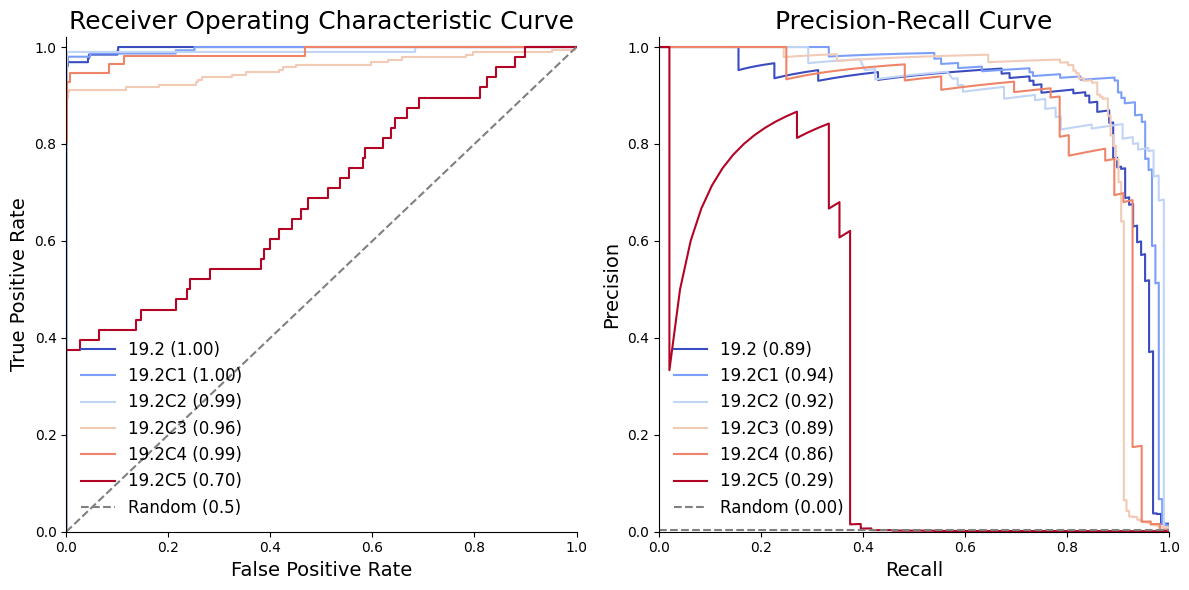

In [6]:
cmap = cm.get_cmap('coolwarm', len(VARIANT_ORDER))
colors = [to_hex(cmap(i)) for i in range(len(VARIANT_ORDER))]

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 6))

for tcr, color in zip(VARIANT_ORDER, colors):
    y_true, y_score = variant_results[tcr]

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=color, lw=1.5, label=f'{tcr} ({roc_auc:.2f})')

    precision, recall, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    ax_pr.plot(recall, precision, color=color, lw=1.5, label=f'{tcr} ({ap:.2f})')

# random baselines
ax_roc.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random (0.5)')
pr_baseline = float(np.mean([yt.mean() for yt, _ in variant_results.values()]))
ax_pr.plot([0, 1], [pr_baseline, pr_baseline], linestyle='--', color='gray',
           label=f'Random ({pr_baseline:.2f})')

for ax, title, xlabel, ylabel in [
    (ax_roc, 'Receiver Operating Characteristic Curve', 'False Positive Rate', 'True Positive Rate'),
    (ax_pr, 'Precision-Recall Curve', 'Recall', 'Precision'),
]:
    ax.set_title(title, fontsize=18)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='lower left', fontsize=12, ncol=1, frameon=False)

plt.tight_layout()
plt.show()